# Specific Test V — Lens Finding & Data Pipelines

Binary classification of galaxy images into lensed vs non-lensed.

#### Approach 

Using a 4-block VGG-style CNN with batch normalization and global average pooling. The class imbalance was handled through two complementary mechanisms:

- `WeightedRandomSampler` — oversamples lenses so each batch is ~50/50, ensuring the model sees useful gradient signal for the minority class on every update
- `BCEWithLogitsLoss(pos_weight=16.58)`— additionally scales the lens loss by $n_{neg}/n_{pos}$, reinforcing sensitivity within each batch

D₄ augmentation (H/V flips + random 90° rotations) encodes approximate rotational invariance.

#### Strategy

Dual imbalance handling via sampler + loss weighting. Single sigmoid output since `pos_weight` is only available in `BCEWithLogitsLoss`. Optimiser is Adam (lr=1e-3, wd=1e-4) with cosine annealing over 30 epochs. Gradient clipping at max_norm=1.0 since `pos_weight` amplifies lens gradients. Early stopping with patience=7 on test AUC, tracked instead of loss because BCE loss is noisy under extreme imbalance while AUC is smooth.

#### Results

| Metric | Value |
|---|---|
| **AUC** | **0.9912** |
| Sensitivity (TPR) | 0.9795 |
| Specificity (TNR) | 0.9446 |
| Precision | 0.1506 |
| F1 | 0.2611 |

In [ ]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); 
np.random.seed(SEED); 
torch.manual_seed(SEED)

device = (
    torch.device('mps') if torch.backends.mps.is_available() else
    torch.device('cuda:0') if torch.cuda.is_available() else
    torch.device('cpu')
)
print('Device:', device)

DATA_ROOT = '../lens-finding-test'

Device: mps


In [29]:
def count_files(directory):
    return len([f for f in os.listdir(directory) if f.endswith('.npy')])

splits = {
    'train_lenses': os.path.join(DATA_ROOT, 'train_lenses'),
    'train_nonlenses': os.path.join(DATA_ROOT, 'train_nonlenses'),
    'test_lenses': os.path.join(DATA_ROOT, 'test_lenses'),
    'test_nonlenses': os.path.join(DATA_ROOT, 'test_nonlenses'),
}
for name, path in splits.items():
    n = count_files(path)
    print(f'{name}: {n} images')

train_imbalance = count_files(splits['train_nonlenses']) / count_files(splits['train_lenses'])
test_imbalance = count_files(splits['test_nonlenses'])  / count_files(splits['test_lenses'])
print(f'\nTrain imbalance ratio: {train_imbalance:.2f}x')
print(f'Test imbalance ratio: {test_imbalance:.2f}x')

train_lenses: 1730 images
train_nonlenses: 28675 images
test_lenses: 195 images
test_nonlenses: 19455 images

Train imbalance ratio: 16.58x
Test  imbalance ratio: 99.77x


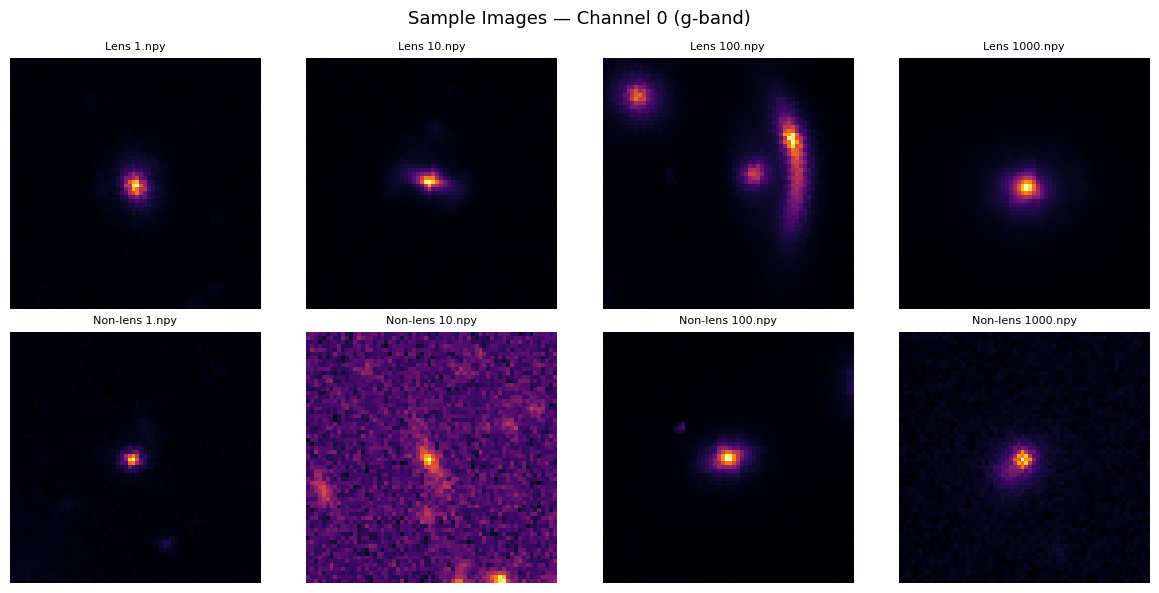

Image shape: (3, 64, 64) | dtype: float32


In [36]:
lens_files = sorted(os.listdir(splits['train_lenses']))[:4]
nonlens_files = sorted(os.listdir(splits['train_nonlenses']))[:4]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample Images — Channel 0 (g-band)', fontsize=13) #any of g/r/i would work for sanity check

for col, fname in enumerate(lens_files):
    img = np.load(os.path.join(splits['train_lenses'], fname))
    axes[0, col].imshow(img[0], cmap='inferno', origin='lower')
    axes[0, col].set_title(f'Lens {fname}', fontsize=8)
    axes[0, col].axis('off')

for col, fname in enumerate(nonlens_files):
    img = np.load(os.path.join(splits['train_nonlenses'], fname))
    axes[1, col].imshow(img[0], cmap='inferno', origin='lower')
    axes[1, col].set_title(f'Non-lens {fname}', fontsize=8)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Lenses', fontsize=10)
axes[1, 0].set_ylabel('Non-lenses', fontsize=10)
plt.tight_layout()
plt.savefig('samples.png', dpi=150)
plt.show()

sample = np.load(os.path.join(splits['train_lenses'], lens_files[0]))
print('Image shape:', sample.shape, '| dtype:', sample.dtype)

In [ ]:
class LensFindingDataset(Dataset):
    def __init__(self, img_paths, labels, train=False):
        self.img_paths = img_paths
        self.labels = labels
        self.train = train

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = np.load(self.img_paths[idx]).astype(np.float32)
        img = (img - img.mean()) / (img.std() + 1e-8)
        t = torch.from_numpy(img)

        if self.train:
            if torch.rand(1) > 0.5:
                t = torch.flip(t, dims=[2])
            if torch.rand(1) > 0.5:
                t = torch.flip(t, dims=[1])
            k = torch.randint(4, (1,)).item()
            t = torch.rot90(t, k, dims=[1, 2])

        return t, torch.tensor(self.labels[idx], dtype=torch.float32)


def build_paths_and_labels(lens_dir, nonlens_dir):
    paths, labels = [], []
    for fname in os.listdir(lens_dir):
        if fname.endswith('.npy'):
            paths.append(os.path.join(lens_dir, fname))
            labels.append(1)
    for fname in os.listdir(nonlens_dir):
        if fname.endswith('.npy'):
            paths.append(os.path.join(nonlens_dir, fname))
            labels.append(0)
    return paths, labels


def make_weighted_loader(paths, labels, batch_size, train=False, num_workers=0):
    dataset = LensFindingDataset(paths, labels, train=train)
    if train:
        n_lens = labels.count(1)
        n_nonlens = labels.count(0)
        w_lens = 1.0 / n_lens
        w_nonlens = 1.0 / n_nonlens
        sample_weights = [w_lens if l == 1 else w_nonlens for l in labels]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(labels),
            replacement=True
        )
        return DataLoader(dataset, batch_size=batch_size, sampler=sampler,
                          num_workers=num_workers, pin_memory=True) 
    return DataLoader(dataset, batch_size=batch_size, shuffle=False,
                      num_workers=num_workers, pin_memory=True)
# set pin_memory=False in order to remove warning, needed for cuda

train_paths, train_labels = build_paths_and_labels(
    splits['train_lenses'], splits['train_nonlenses'])
test_paths, test_labels = build_paths_and_labels(
    splits['test_lenses'],  splits['test_nonlenses'])

BATCH_SIZE = 64
train_loader = make_weighted_loader(train_paths, train_labels, BATCH_SIZE, train=True)
test_loader = make_weighted_loader(test_paths,  test_labels,  BATCH_SIZE, train=False)

print(f'Train: {len(train_paths)} samples  ({train_labels.count(1)} lenses, {train_labels.count(0)} non-lenses)')
print(f'Test: {len(test_paths)} samples  ({test_labels.count(1)} lenses, {test_labels.count(0)} non-lenses)')


Train: 30405 samples  (1730 lenses, 28675 non-lenses)
Test: 19650 samples  (195 lenses, 19455 non-lenses)


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
    def forward(self, x): return self.net(x)


class LensFinderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.head(self.pool(self.features(x)))


model = LensFinderCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')

Parameters: 1,206,241


In [ ]:
def train_one_epoch(loader, model, criterion, optimizer):
    model.train()
    total_loss = 0.0
    all_logits, all_targets = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x).squeeze(1)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        all_logits.append(logits.detach().cpu())
        all_targets.append(y.cpu())
    all_probs   = torch.sigmoid(torch.cat(all_logits)).numpy()
    all_targets = torch.cat(all_targets).numpy()
    return total_loss / len(loader), roc_auc_score(all_targets, all_probs)


@torch.no_grad()
def evaluate(loader, model, criterion):
    model.eval()
    total_loss = 0.0
    all_logits, all_targets = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x).squeeze(1)
        total_loss += criterion(logits, y).item()
        all_logits.append(logits.cpu())
        all_targets.append(y.cpu())
    all_probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    all_targets = torch.cat(all_targets).numpy()
    return total_loss / len(loader), roc_auc_score(all_targets, all_probs), all_probs, all_targets


n_pos = train_labels.count(1)
n_neg = train_labels.count(0)
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f'pos_weight = {pos_weight.item():.2f} (n_neg={n_neg}, n_pos={n_pos})')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

EPOCHS = 30
PATIENCE = 7

history = {'train_loss': [], 'train_auc': [], 'test_loss': [], 'test_auc': []}
best_auc, patience_counter = 0.0, 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc = train_one_epoch(train_loader, model, criterion, optimizer)
    te_loss, te_auc, _, _ = evaluate(test_loader, model, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_auc'].append(tr_auc)
    history['test_loss'].append(te_loss)
    history['test_auc'].append(te_auc)

    flag = ''
    if te_auc > best_auc:
        best_auc = te_auc
        patience_counter = 0
        torch.save(model.state_dict(), 'test5_best.pth')
        flag = '  <- saved'
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

    print(f'Epoch {epoch:>2}/{EPOCHS} | '
          f'Train loss={tr_loss:.4f} AUC={tr_auc:.4f} | '
          f'Test  loss={te_loss:.4f} AUC={te_auc:.4f}{flag}')

pos_weight = 16.58  (n_neg=28675, n_pos=1730)


/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test1/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test1/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/30 | Train loss=0.8782 AUC=0.9493 | Test  loss=0.7734 AUC=0.9532  <- saved


/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test1/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test1/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch  2/30 | Train loss=0.7103 AUC=0.9669 | Test  loss=1.3871 AUC=0.9644  <- saved


...

Epoch 28/30 | Train loss=0.1562 AUC=0.9966 | Test  loss=0.1820 AUC=0.9912  <- saved


/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test1/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test1/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 29/30 | Train loss=0.1371 AUC=0.9960 | Test  loss=0.1984 AUC=0.9910


/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test1/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test1/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 30/30 | Train loss=0.1542 AUC=0.9965 | Test  loss=0.2338 AUC=0.9905


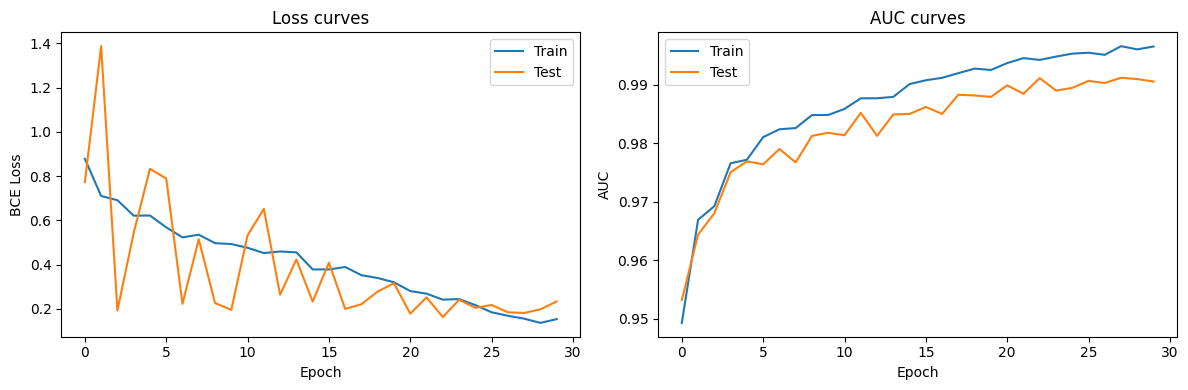

Best test AUC: 0.9912


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['test_loss'],  label='Test')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss curves'); ax1.legend()

ax2.plot(history['train_auc'], label='Train')
ax2.plot(history['test_auc'],  label='Test')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('AUC curves'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print(f'Best test AUC: {best_auc:.4f}')

/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test1/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


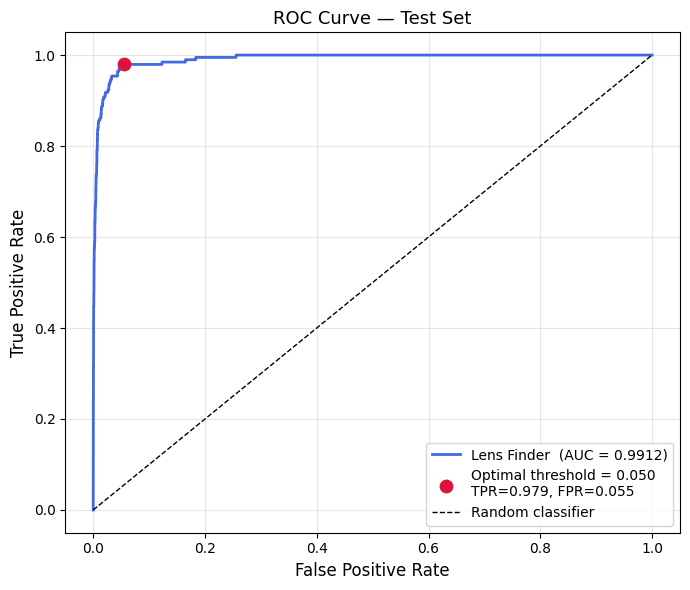

Test AUC : 0.9912


In [ ]:
model.load_state_dict(torch.load('test5_best.pth', map_location=device, weights_only=True))
_, final_auc, test_probs, test_targets = evaluate(test_loader, model, criterion)

fpr, tpr, thresholds = roc_curve(test_targets, test_probs)
roc_auc = auc(fpr, tpr)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thr = thresholds[best_idx]
best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='royalblue', lw=2,
        label=f'Lens Finder  (AUC = {roc_auc:.4f})')
ax.scatter([best_fpr], [best_tpr], s=80, zorder=5, color='crimson',
           label=f'Optimal threshold = {best_thr:.3f}\nTPR={best_tpr:.3f}, FPR={best_fpr:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Test Set', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print(f'Test AUC: {roc_auc:.4f}')

In [ ]:
y_pred = (test_probs >= best_thr).astype(int)
cm = confusion_matrix(test_targets, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp + 1e-9)
f1 = 2 * precision * sensitivity / (precision + sensitivity + 1e-9)

print('Confusion Matrix (rows=actual, cols=predicted):')
print(f'                    Predicted Non-lens  Predicted Lens')
print(f'Actual Non-lens         {tn:7d}         {fp:7d}')
print(f'Actual Lens             {fn:7d}         {tp:7d}')
print()
print(f'Sensitivity (TPR / Recall): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'Precision: {precision:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'AUC: {roc_auc:.4f}')

Confusion Matrix (rows=actual, cols=predicted):
                    Predicted Non-lens  Predicted Lens
Actual Non-lens           18378            1077
Actual Lens                   4             191

Sensitivity (TPR / Recall): 0.9795
Specificity (TNR): 0.9446
Precision: 0.1506
F1 Score: 0.2611
AUC: 0.9912
